<a href="https://colab.research.google.com/github/rodolfocustodio/transfer-learning/blob/main/image_similarity_recommendations_dio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Step 1: Data Acquisition

Download the pre-trained image model and add two additional layers on top of that: the first layer is a feature vector layer and the second layer is the classification layer. We will only train these 2 layers on our data and after training, we will select the feature vector layer as the output of our fine-tuned encoder. After fine-tuning the model, we will save the feature extractor for later use.

In [ ]:
import itertools
import os

import matplotlib.pylab as plt
import numpy as np

import tensorflow as tf
import tensorflow_hub as hub

print("TF version:", tf.__version__)
print("Hub version:", hub.__version__)
print("GPU is", "available" if tf.config.list_physical_devices('GPU') else "NOT AVAILABLE")

TF version: 2.19.0
Hub version: 0.16.1
GPU is available


In [ ]:
MODULE_HANDLE = 'https://tfhub.dev/google/bit/m-r50x3/1'
IMAGE_SIZE = (224, 224)
print("Using {} with input size {}".format(MODULE_HANDLE, IMAGE_SIZE))
BATCH_SIZE = 12
N_FEATURES = 256

Using https://tfhub.dev/google/bit/m-r50x3/1 with input size (224, 224)


In [ ]:
#hide

from google.colab import drive
drive.mount('/content/drive')

data_dir = '/content/drive/MyDrive/categorias'



Mounted at /content/drive


In [ ]:
datagen_kwargs = dict(rescale=1./255, validation_split=.20)
dataflow_kwargs = dict(target_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                   interpolation="bilinear")

valid_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    **datagen_kwargs)
# Create a copy of dataflow_kwargs for validation and set its batch_size
valid_dataflow_kwargs = dataflow_kwargs.copy()
valid_dataflow_kwargs['batch_size'] = 4
valid_generator = valid_datagen.flow_from_directory(
    data_dir, subset="validation", shuffle=False, **valid_dataflow_kwargs)

do_data_augmentation = False
if do_data_augmentation:
  train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
      rotation_range=40,
      horizontal_flip=True,
      width_shift_range=0.2, height_shift_range=0.2,
      shear_range=0.2, zoom_range=0.2,
      **datagen_kwargs)
else:
  train_datagen = valid_datagen
train_generator = train_datagen.flow_from_directory(
    data_dir, subset="training", shuffle=True, **dataflow_kwargs)

Found 4 images belonging to 5 classes.
Found 32 images belonging to 5 classes.


In [ ]:
tf.keras.backend.clear_session()
print("Building model with", MODULE_HANDLE)

# Use Keras Functional API to build the model
inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))

# Wrap the hub.KerasLayer instantiation and call within a Lambda layer.
# This helps in properly handling symbolic tensors by the TF Hub module
# and reshapes its 4D output (e.g., (None, 1, 1, 2048)) into a 2D tensor (e.g., (None, 2048)).
x = tf.keras.layers.Lambda(
    lambda t: tf.reshape(hub.KerasLayer(MODULE_HANDLE, trainable=False)(t, training=False), (-1, 2048)),
    output_shape=(2048,)
)(inputs)

# The Flatten layer is no longer needed as the Lambda layer already reshapes the output.
x = tf.keras.layers.Dropout(rate=0.2)(x)
x = tf.keras.layers.Dense(N_FEATURES,
                          kernel_regularizer=tf.keras.regularizers.l2(0.0001))(x)
x = tf.keras.layers.Dropout(rate=0.2)(x)
outputs = tf.keras.layers.Dense(train_generator.num_classes,
                          kernel_regularizer=tf.keras.regularizers.l2(0.0001))(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

model.summary()

Building model with https://tfhub.dev/google/bit/m-r50x3/1


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,829 (2.01 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define optimiser and loss
lr = 0.003 * BATCH_SIZE / 512
SCHEDULE_LENGTH = 500
SCHEDULE_BOUNDARIES = [200, 300, 400]

# Decay learning rate by a factor of 10 at SCHEDULE_BOUNDARIES.
lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(boundaries=SCHEDULE_BOUNDARIES,
                                                                   values=[lr, lr*0.1, lr*0.001, lr*0.0001])
optimizer = tf.keras.optimizers.SGD(learning_rate=lr_schedule, momentum=0.9)

loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)

model.compile(optimizer=optimizer,
              loss=loss_fn) #,
              #metrics=['accuracy'])

In [ ]:
steps_per_epoch = train_generator.samples // train_generator.batch_size
validation_steps = valid_generator.samples // valid_generator.batch_size

# Debugging: Inspect generator output shapes
print(f"Number of classes: {train_generator.num_classes}")

for i, (images, labels) in enumerate(train_generator):
    print(f"Train Generator Batch {i}: Images shape {images.shape}, Labels shape {labels.shape}")
    break # Only check the first batch

for i, (images, labels) in enumerate(valid_generator):
    print(f"Valid Generator Batch {i}: Images shape {images.shape}, Labels shape {labels.shape}")
    break # Only check the first batch

# Ensure validation_steps is at least 1 for valid_generator to be used, if samples exist
if valid_generator.samples > 0 and validation_steps == 0:
    print(f"Warning: validation_steps is 0 despite {valid_generator.samples} validation samples. Setting validation_steps to 1.")
    validation_steps = 1 # Set to 1 to allow validation to run at least once if there are samples

# Disable XLA compilation to avoid potential graph execution errors with specific shapes
tf.config.optimizer.set_jit(False)

# To diagnose the "Incompatible shapes" error, let's try training without the 'accuracy' metric first.
# If this resolves the issue, the problem lies within the accuracy metric's calculation.
hist = model.fit(
    train_generator,
    epochs=1, steps_per_epoch=steps_per_epoch,
    validation_data=valid_generator,
    validation_steps=validation_steps).history


NameError: name 'hist' is not defined

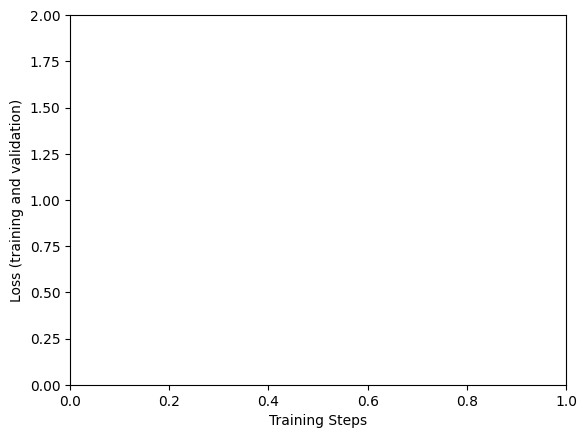

In [ ]:
#hide
plt.figure()
plt.ylabel("Loss (training and validation)")
plt.xlabel("Training Steps")
plt.ylim([0,2])
plt.plot(hist["loss"])
plt.plot(hist["val_loss"])

plt.figure()
plt.ylabel("Accuracy (training and validation)")
plt.xlabel("Training Steps")
plt.ylim([0,1])
plt.plot(hist["accuracy"])
plt.plot(hist["val_accuracy"])

In [ ]:
feature_extractor = tf.keras.Model(inputs=model.inputs, outputs=model.layers[-3].output)
feature_extractor.save('/content/bit_feature_extractor.keras')

saved_model_path = '/content/bit_model.keras' # Added .keras extension
model.save(saved_model_path)

### Step 3: Image Vectorization
Now, we will use the encoder (prepared in step 2) to encode the images (prepared in step 1). We will save feature vector of each image as an array in a directory. After processing, we will save these embeddings for later use.

In [ ]:
#hide
import tensorflow as tf
from pathlib import Path
import numpy as np
import os
from tqdm import tqdm
tqdm.pandas()

In [ ]:
img_paths = []
for path in Path('/content/drive/MyDrive/categorias').rglob('*.jpg'):
  img_paths.append(path)
np.random.shuffle(img_paths)

In [ ]:
def load_img(path):
  img = tf.io.read_file(path)
  img = tf.io.decode_jpeg(img, channels=3)
  img = tf.image.resize_with_pad(img, 224, 224)
  img  = tf.image.convert_image_dtype(img, tf.float32)[tf.newaxis, ...]
  return img

In [ ]:
TRANSFER_LEARNING_FLAG = 1
if TRANSFER_LEARNING_FLAG:
  module = tf.keras.models.load_model('/content/bit_feature_extractor.keras', safe_mode=False)
else:
  module_handle = "https://tfhub.dev/google/bit/s-r50x3/ilsvrc2012_classification/1"
  module = hub.load(module_handle)

In [ ]:
imgvec_path = '/content/img_vectors/'
Path(imgvec_path).mkdir(parents=True, exist_ok=True)

In [ ]:
for filename in tqdm(img_paths[:5000]):
    img = load_img(str(filename))
    features = module(img)
    feature_set = np.squeeze(features)
    outfile_name = os.path.basename(filename).split('.')[0] + ".npz"
    out_path_file = os.path.join(imgvec_path, outfile_name)
    np.savetxt(out_path_file, feature_set, delimiter=',')

### Step 4: Metadata and Indexing

We will assign a unique id to each image and create dictionaries to locate information of this image: 1) Image id to Image name dictionary, 2) Image id to image feature vector dictionary, and 3) (optional) Image id to metadata product id dictionary. We will also create an image id to image feature vector indexing. Then we will save these dictionaries and index object for later use.

In [ ]:
#hide
import pandas as pd
import glob
import os
import numpy as np
from tqdm import tqdm
tqdm.pandas()
!pip install -q annoy
import json
from annoy import AnnoyIndex
from scipy import spatial
import pickle
from IPython.display import Image as dispImage

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 647.5/647.5 kB 13.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


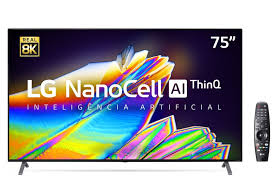

In [ ]:
test_img = '/content/drive/MyDrive/categorias/televisor/1.jpg'
dispImage(test_img)

In [ ]:
#hide-output
styles = pd.read_csv('/content/styles.csv', error_bad_lines=False)
styles['id'] = styles['id'].astype('str')
styles.to_csv(root_path+'/styles.csv', index=False)

In [ ]:
def match_id(fname):
  return styles.index[styles.id==fname].values[0]

In [ ]:
# Defining data structures as empty dict
file_index_to_file_name = {}
file_index_to_file_vector = {}
file_index_to_product_id = {}

# Configuring annoy parameters
dims = 256
n_nearest_neighbors = 20
trees = 10000

# Reads all file names which stores feature vectors
allfiles = glob.glob('/content/img_vectors/*.npz')

t = AnnoyIndex(dims, metric='angular')

In [ ]:
for findex, fname in tqdm(enumerate(allfiles)):
  file_vector = np.loadtxt(fname)
  file_name = os.path.basename(fname).split('.')[0]
  file_index_to_file_name[findex] = file_name
  file_index_to_file_vector[findex] = file_vector
  try:
    file_index_to_product_id[findex] = match_id(file_name)
  except IndexError:
    pass
  t.add_item(findex, file_vector)

0it [00:00, ?it/s]


In [ ]:
#hide-output
t.build(trees)
t.save('t.ann')

True

In [ ]:
#hide
file_path = '/content/drive/MyDrive/categorias/'

In [ ]:
t.save(file_path+'indexer.ann')
pickle.dump(file_index_to_file_name, open(file_path+"file_index_to_file_name.p", "wb"))
pickle.dump(file_index_to_file_vector, open(file_path+"file_index_to_file_vector.p", "wb"))
pickle.dump(file_index_to_product_id, open(file_path+"file_index_to_product_id.p", "wb"))

## Step 5: Local Testing

We will load a random image and find top-K most similar images.

In [ ]:
#hide
from PIL import Image
import matplotlib.image as mpimg

In [ ]:
img_addr = 'https://images-na.ssl-images-amazon.com/images/I/81%2Bd6eSA0eL._UL1500_.jpg'

!wget -q -O img.jpg $img_addr
test_img = 'img.jpg'
topK = 4

test_vec = np.squeeze(module(load_img(test_img)))

basewidth = 224
img = Image.open(test_img)
wpercent = (basewidth/float(img.size[0]))
hsize = int((float(img.size[1])*float(wpercent)))
img = img.resize((basewidth,hsize), Image.ANTIALIAS)
img

In [ ]:
path_dict = {}
for path in Path('/content/drive/MyDrive/categorias').rglob('*.jpg'):
  path_dict[path.name] = path

nns = t.get_nns_by_vector(test_vec, n=topK)
plt.figure(figsize=(20, 10))
for i in range(topK):
  x = file_index_to_file_name[nns[i]]
  x = path_dict[x+'.jpg']
  y = file_index_to_product_id[nns[i]]
  title = '\n'.join([str(j) for j in list(styles.loc[y].values[-5:])])
  plt.subplot(1, topK, i+1)
  plt.title(title)
  plt.imshow(mpimg.imread(x))
  plt.axis('off')
plt.tight_layout()

## Step 6: API Call

We will build two kinds of API - 1) UI based API using Streamlit, and 2) REST API using Flask. In both the cases, we will receive an image from user, encode it with our image encoder, find TopK similar vectors using Indexing object, and retrieve the image (and metadata) using dictionaries. We send these images (and metadata) back to the user.

In [ ]:
#hide
import os
import time

In [ ]:
#hide
root_path = '/content/drive/MyDrive/categorias'

In [ ]:
%%writefile utils.py
### ----utils.py---- ###

import os
import tensorflow as tf
from annoy import AnnoyIndex

root_path = '/content/drive/MyDrive/categorias'

class Encoder:
  encoder = tf.keras.models.load_model(os.path.join(root_path, 'bit_feature_extractor'))

class Indexer:
  dims = 256
  topK = 6
  indexer = AnnoyIndex(dims, 'angular')
  indexer.load(os.path.join(root_path, 'indexer.ann'))

encoder = Encoder()
indexer = Indexer()

Writing utils.py
